In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import files
input_file=files.upload()

Saving heart.csv to heart (1).csv


In [ ]:
ds=pd.read_csv("heart.csv")

In [ ]:
print(ds.head())

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


In [ ]:
Le=LabelEncoder()
ds['Sex']=Le.fit_transform(ds['Sex'])
ds['ChestPainType']=Le.fit_transform(ds['ChestPainType'])
ds['RestingECG']=Le.fit_transform(ds['RestingECG'])
ds['ExerciseAngina']=Le.fit_transform(ds['ExerciseAngina'])
ds['ST_Slope']=Le.fit_transform(ds['ST_Slope'])

In [ ]:
ds.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    int64  
 2   ChestPainType   918 non-null    int64  
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    int64  
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    int64  
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    int64  
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 86.2 KB


In [ ]:
ds.describe()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,0.789760,0.781046,132.396514,198.799564,0.233115,0.989107,136.809368,0.404139,0.887364,1.361656,0.553377
std,9.432617,0.407701,0.956519,18.514154,109.384145,0.423046,0.631671,25.460334,0.490992,1.066570,0.607056,0.497414
min,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,0.000000,120.000000,173.250000,0.000000,1.000000,120.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,0.000000,130.000000,223.000000,0.000000,1.000000,138.000000,0.000000,0.600000,1.000000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,267.000000,0.000000,1.000000,156.000000,1.000000,1.500000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,1.000000


In [ ]:
ds.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


<Axes: >

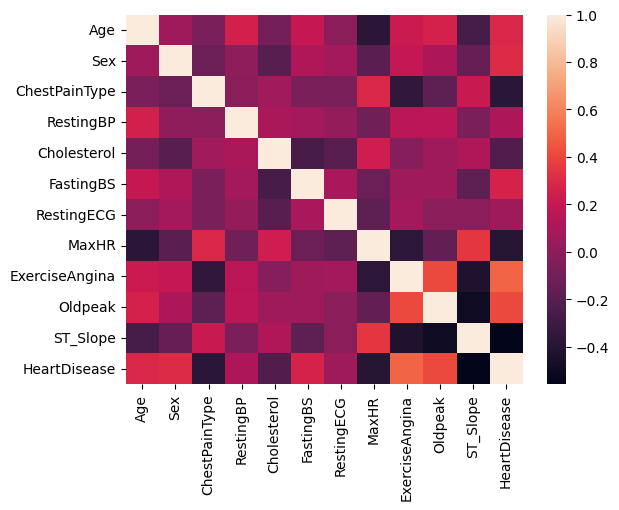

In [ ]:
#Heat map to check correlation
sns.heatmap(ds.corr())

In [ ]:
X=ds.drop('HeartDisease',axis=1)
y=ds['HeartDisease']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
#model training
from sklearn.ensemble import RandomForestClassifier
RFC=RandomForestClassifier(n_estimators=100,random_state=42)
RFC.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
GBC=GradientBoostingClassifier(n_estimators=100,random_state=42)
GBC.fit(X_train,y_train)


GradientBoostingClassifier(random_state=42)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
ABC=AdaBoostClassifier(n_estimators=100,random_state=42)
ABC.fit(X_train,y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [ ]:
from xgboost import XGBClassifier
XGB=XGBClassifier(n_estimators=100,random_state=42)
XGB.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.ensemble import VotingClassifier
VC=VotingClassifier(estimators=[('RFC',RFC),('GBC',GBC),('ABC',ABC),('XGB',XGB)],voting='soft')
VC.fit(X_train,y_train)

VotingClassifier(estimators=[('RFC', RandomForestClassifier(random_state=42)),
                             ('GBC',
                              GradientBoostingClassifier(random_state=42)),
                             ('ABC',
                              AdaBoostClassifier(n_estimators=100,
                                                 random_state=42)),
                             ('XGB',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_r...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(y_true, y_pred, model_name="Model"):

    print(f"\n{model_name} Evaluation")
    print("-" * 30)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score :", f1_score(y_true, y_pred, average='weighted'))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

In [ ]:
evaluate_model(y_test,VC.predict(X_test),"Voting Classifier")
evaluate_model(y_test,RFC.predict(X_test),"Random Forest Classifier")
evaluate_model(y_test,GBC.predict(X_test),"Gradient Boost Classifier")
evaluate_model(y_test,ABC.predict(X_test),"AdaBoost Classifier")
evaluate_model(y_test,XGB.predict(X_test),"XGBoost Classifier")


Voting Classifier Evaluation
------------------------------
Accuracy : 0.8695652173913043
Precision: 0.8725526298046252
Recall   : 0.8695652173913043
F1 Score : 0.8701295986622073

Confusion Matrix:
[[68  9]
 [15 92]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        77
           1       0.91      0.86      0.88       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184


Random Forest Classifier Evaluation
------------------------------
Accuracy : 0.8804347826086957
Precision: 0.8804347826086957
Recall   : 0.8804347826086957
F1 Score : 0.8804347826086957

Confusion Matrix:
[[66 11]
 [11 96]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        77
           1       0.90      0.90      0.90       107

    accuracy    

In [ ]:
results = pd.DataFrame({
    'Model':['RFC','GBC','ABC','XGB','Voting'],
    'Accuracy':[
        accuracy_score(y_test,RFC.predict(X_test)),
        accuracy_score(y_test,GBC.predict(X_test)),
        accuracy_score(y_test,ABC.predict(X_test)),
        accuracy_score(y_test,XGB.predict(X_test)),
        accuracy_score(y_test,VC.predict(X_test))
    ]
})
print(results)

    Model  Accuracy
0     RFC  0.880435
1     GBC  0.875000
2     ABC  0.869565
3     XGB  0.869565
4  Voting  0.869565
